In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from fastai.vision import *
import torch
import torch.nn as nn
from torchvision.models import resnet50
import timm

In [2]:
path = 'Downloads/Skin_cancer_dataset'
csv_file = 'Downloads/Skin_cancer_dataset/HAM10000_metadata.csv'

In [3]:
df = pd.read_csv(csv_file).set_index('image_id')
df

,lesion_id,dx,dx_type,age,sex,localization,dataset
image_id,,,,,,,
ISIC_0027419,HAM_0000118,bkl,histo,80.0,male,scalp,vidir_modern
ISIC_0025030,HAM_0000118,bkl,histo,80.0,male,scalp,vidir_modern
ISIC_0026769,HAM_0002730,bkl,histo,80.0,male,scalp,vidir_modern
ISIC_0025661,HAM_0002730,bkl,histo,80.0,male,scalp,vidir_modern
ISIC_0031633,HAM_0001466,bkl,histo,75.0,male,ear,vidir_modern
...,...,...,...,...,...,...,...
ISIC_0033084,HAM_0002867,akiec,histo,40.0,male,abdomen,vidir_modern
ISIC_0033550,HAM_0002867,akiec,histo,40.0,male,abdomen,vidir_modern
ISIC_0033536,HAM_0002867,akiec,histo,40.0,male,abdomen,vidir_modern


In [4]:
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis ',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

In [5]:
df.dx=df.dx.astype('category',copy=True)
df['labels']=df.dx.cat.codes
df['lesion']= df.dx.map(lesion_type_dict)
df

,lesion_id,dx,dx_type,age,sex,localization,dataset,labels,lesion
image_id,,,,,,,,,
ISIC_0027419,HAM_0000118,bkl,histo,80.0,male,scalp,vidir_modern,2,Benign keratosis
ISIC_0025030,HAM_0000118,bkl,histo,80.0,male,scalp,vidir_modern,2,Benign keratosis
ISIC_0026769,HAM_0002730,bkl,histo,80.0,male,scalp,vidir_modern,2,Benign keratosis
ISIC_0025661,HAM_0002730,bkl,histo,80.0,male,scalp,vidir_modern,2,Benign keratosis
ISIC_0031633,HAM_0001466,bkl,histo,75.0,male,ear,vidir_modern,2,Benign keratosis
...,...,...,...,...,...,...,...,...,...
ISIC_0033084,HAM_0002867,akiec,histo,40.0,male,abdomen,vidir_modern,0,Actinic keratoses
ISIC_0033550,HAM_0002867,akiec,histo,40.0,male,abdomen,vidir_modern,0,Actinic keratoses
ISIC_0033536,HAM_0002867,akiec,histo,40.0,male,abdomen,vidir_modern,0,Actinic keratoses


In [6]:
print(df.lesion.value_counts())

lesion
Melanocytic nevi        6705
Melanoma                1113
Benign keratosis        1099
Basal cell carcinoma     514
Actinic keratoses        327
Vascular lesions         142
Dermatofibroma           115
Name: count, dtype: int64


<Axes: xlabel='count', ylabel='lesion'>

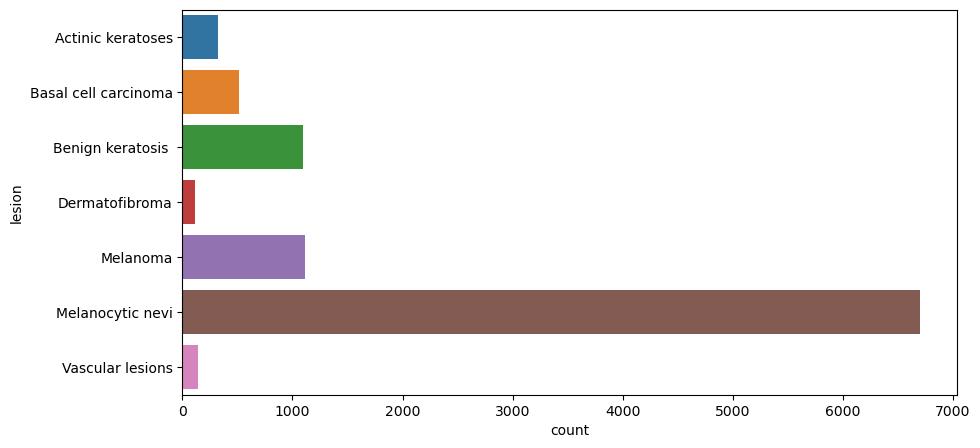

In [7]:
fig, ax1 = plt.subplots(1, 1, figsize = (10, 5))
sns.countplot(y='lesion',data=df, hue="lesion",ax=ax1)

In [8]:
class CustomImageItemList(ImageList):
    def custom_label(self, df, **kwargs) -> 'LabelList':
        file_names = [p.stem for p in self.items]
        get_labels = lambda x: df.loc[x, 'lesion']
        labels = get_labels(file_names)
        y = CategoryList(items=labels)
        res = self._label_list(x=self, y=y)
        return res

In [9]:
import torch
import fastai.vision.transform
 
def patched_solve(B, A):
    return torch.linalg.solve(A, B), None
fastai.vision.transform._solve_func = patched_solve

In [10]:
def get_data(bs, size):
    train_ds = (CustomImageItemList.from_folder('Downloads/Skin_cancer_dataset/HAM10000_images_part_1', extensions='.jpg')
                    .random_split_by_pct(0.15)
                    .custom_label(df)
                    .transform(tfms=get_transforms(flip_vert=True),size=size)
                    .databunch(num_workers=0, bs=bs)
                    .normalize(imagenet_stats))
    return train_ds

In [11]:
data=get_data(16,224)
data

C:\Users\Akshat Bhatt\anaconda3\Lib\site-packages\fastai\data_block.py:217: UserWarning: `random_split_by_pct` is deprecated, please use `split_by_rand_pct`.
  warn("`random_split_by_pct` is deprecated, please use `split_by_rand_pct`.")


ImageDataBunch;

Train: LabelList (4250 items)
x: CustomImageItemList
Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224)
y: CategoryList
Melanocytic nevi,Melanocytic nevi,Melanoma,Melanoma,Melanoma
Path: Downloads\Skin_cancer_dataset\HAM10000_images_part_1;

Valid: LabelList (750 items)
x: CustomImageItemList
Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224),Image (3, 224, 224)
y: CategoryList
Melanocytic nevi,Basal cell carcinoma,Benign keratosis ,Melanocytic nevi,Melanocytic nevi
Path: Downloads\Skin_cancer_dataset\HAM10000_images_part_1;

Test: None

In [22]:
data.classes=list(np.unique(df.lesion))  
data.c= len(np.unique(df.lesion))

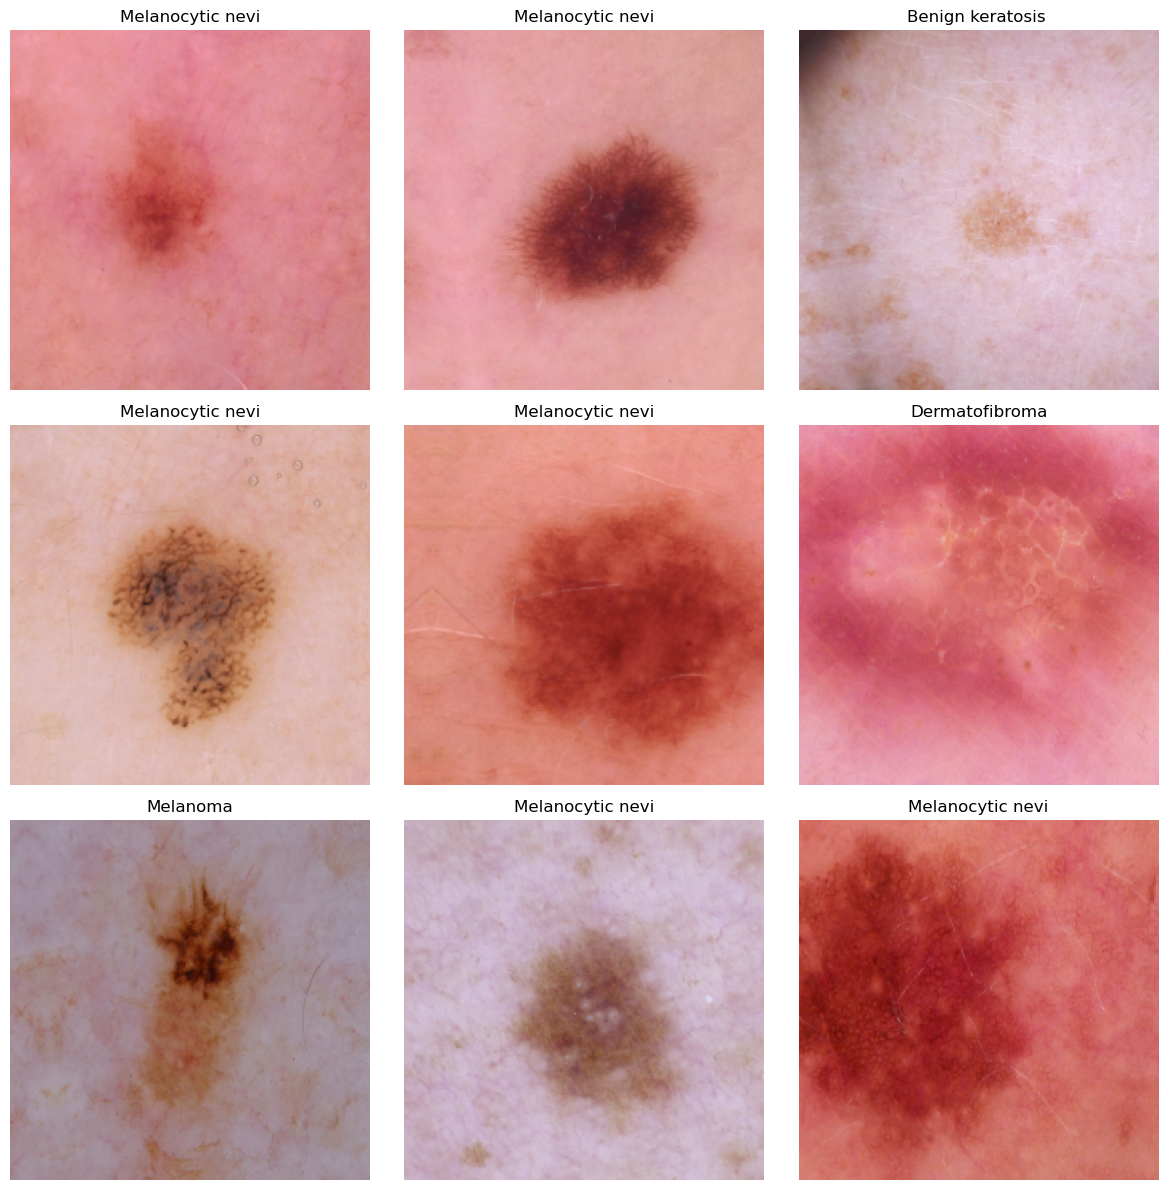

In [23]:
data.show_batch(rows=3)

Loading EfficientNet-B3...


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

C:\Users\Akshat Bhatt\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Akshat Bhatt\.cache\huggingface\hub\models--timm--efficientnet_b3.ra2_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Training started...


epoch,train_loss,valid_loss,accuracy,time
0,0.815115,0.735785,0.741333,23:46
1,0.695754,0.685955,0.781333,14:21
2,0.590708,0.556544,0.806667,14:07
3,0.369718,0.442641,0.850667,14:19
4,0.254544,0.415700,0.865333,14:19


Saving model files...
Plotting results...


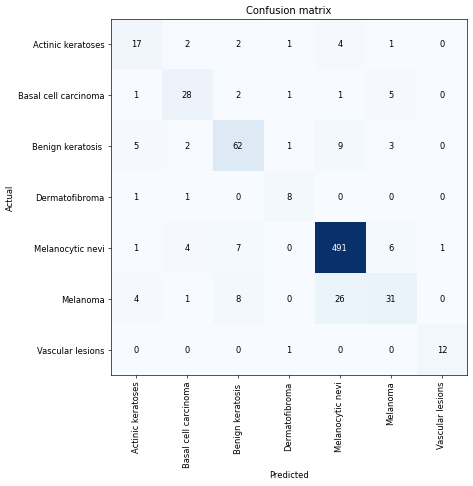

In [21]:
print("Loading EfficientNet-B3...")
model_eff = timm.create_model('efficientnet_b3', pretrained=True, num_classes=data.c)
learn_eff = Learner(data, model_eff, metrics=accuracy)
print("Training started...")
learn_eff.fit_one_cycle(5, max_lr=1e-3)
print("Saving model files...")
learn_eff.save('efficientnet-b3-weights')
learn_eff.export('efficientnet-b3-deployment.pkl')
print("Plotting results...")
interp_eff = ClassificationInterpretation.from_learner(learn_eff)
interp_eff.plot_confusion_matrix(figsize=(8,8), dpi=60)